<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Dinidi(BiLSTM)/fake_news_bi_lstm_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 2) Imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Upload kaggle.json and download dataset automatically
from google.colab import files
files.upload()  # Upload kaggle.json (from your Kaggle account)

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p ./data
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p ./data
!unzip -q ./data/fake-and-real-news-dataset.zip -d ./data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 1.55GB/s]


In [3]:
# 3) Load CSVs
fake_path = './data/Fake.csv'
true_path = './data/True.csv'

if not (os.path.exists(fake_path) and os.path.exists(true_path)):
  raise FileNotFoundError('Expected data/Fake.csv and data/True.csv. Download the Kaggle dataset and unzip to ./data')

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)


print('Fake shape:', df_fake.shape)
print('True shape:', df_true.shape)


# quick peek
print(df_fake.columns)
print(df_true.columns)

Fake shape: (23481, 4)
True shape: (21417, 4)
Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [4]:
# 4) Combine and label
df_fake['label'] = 1 # 1 = fake
df_true['label'] = 0 # 0 = real


# keep only useful columns (title + text are useful). We'll use 'text' primarily.
for col in ['title','text','subject','date','label']:
  if col not in df_fake.columns:
    print('Warning: column',col,'missing in Fake.csv')


df = pd.concat([df_fake[['title','text','label']], df_true[['title','text','label']]], axis=0).reset_index(drop=True)
print('Combined shape:', df.shape)


# shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

Combined shape: (44898, 3)


label
1    23481
0    21417
Name: count, dtype: int64
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   

                                                text  label  
0  21st Century Wire says Ben Stein, reputable pr...      1  
1  WASHINGTON (Reuters) - U.S. President Donald T...      0  
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...      0  


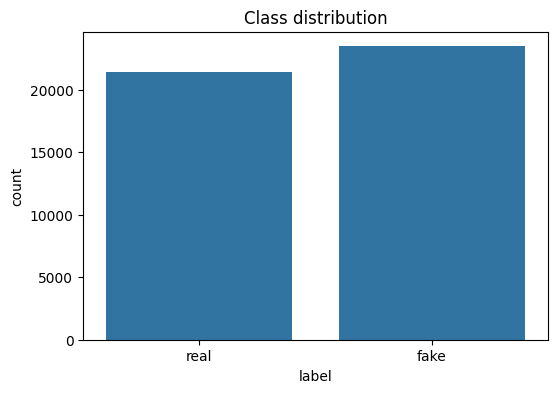

In [5]:
# 5) Quick EDA
print(df['label'].value_counts())
print(df.head(3))


plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['real','fake'])
plt.title('Class distribution')
plt.show()

In [6]:
import re

# List of common publishers to remove
publishers = ["Reuters", "CNN", "BBC", "NYT", "Fox News", "NBC", "AP", "Washington Post", "CBS"]

def clean_text(text):
    # Remove publisher names (case-insensitive)
    for pub in publishers:
        text = re.sub(rf'\b{pub}\b', '', text, flags=re.IGNORECASE)

    # Remove dates in formats like "31-Dec-17", "Dec 28, 2017", "12/31/17"
    text = re.sub(r'\b\d{1,2}[-/][A-Za-z]{3,}[-/]\d{2,4}\b', '', text)
    text = re.sub(r'\b[A-Za-z]{3,}\s\d{1,2},\s\d{4}\b', '', text)

    # Remove extra whitespaces and leftover punctuation from removal
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Example usage:
sample_text = "WASHINGTON (Reuters) - Transgender people will be allowed for the first time..."
cleaned = clean_text(sample_text)
print(cleaned)


WASHINGTON () - Transgender people will be allowed for the first time...


In [7]:
# 6) Text cleaning / preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))


def clean_text(text, remove_stopwords=True):
  text = str(text)
  text = text.lower()
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r"http\S+|www\S+", ' ', text) # remove urls
  text = re.sub(r'[^a-z ]', ' ', text)
  tokens = text.split()
  if remove_stopwords:
    tokens = [t for t in tokens if t not in STOP]
  return ' '.join(tokens)


# apply (may take a minute)
df['clean_text'] = df['text'].astype(str).apply(lambda x: clean_text(x, remove_stopwords=True))


# quick check
print(df['clean_text'].str.len().describe())
print(df.loc[0, 'clean_text'][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


count    44898.000000
mean      1722.097087
std       1533.043181
min          0.000000
25%        860.250000
50%       1506.000000
75%       2153.000000
max      38855.000000
Name: clean_text, dtype: float64
st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit co


In [8]:
# 7) Baseline: TF-IDF + Logistic Regression (fast baseline)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


X = df['clean_text']
y = df['label'].values


# train/test split (stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)


tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)


preds_lr = lr.predict(X_test_tfidf)
print('\nBaseline (TF-IDF + LR) classification report:\n')
print(classification_report(y_test, preds_lr, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:,1]))


# Save baseline artifacts
import pickle
os.makedirs('./artifacts', exist_ok=True)
with open('./artifacts/tfidf.pkl','wb') as f:
  pickle.dump(tfidf, f)
with open('./artifacts/lr_model.pkl','wb') as f:
  pickle.dump(lr, f)


Baseline (TF-IDF + LR) classification report:

              precision    recall  f1-score   support

           0     0.9833    0.9916    0.9874      4284
           1     0.9923    0.9847    0.9885      4696

    accuracy                         0.9880      8980
   macro avg     0.9878    0.9881    0.9880      8980
weighted avg     0.9880    0.9880    0.9880      8980

ROC-AUC: 0.9991353369854472


In [9]:
# 8) Prepare data for deep learning (tokenize + pad)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_VOCAB = 20000
MAX_LEN = 300
EMBEDDING_DIM = 100


tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text) # fit only on training set to avoid leakage


X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)


X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


print('X_train_pad shape:', X_train_pad.shape)


# save tokenizer
with open('./artifacts/tokenizer.pkl','wb') as f:
  pickle.dump(tokenizer, f)

X_train_pad shape: (35918, 300)


In [11]:
# 10) Build BiLSTM model (Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)


model = Sequential()

model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN))


model.add(SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 11) Train (with callbacks)
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = ModelCheckpoint('./artifacts/best_bilstm.h5', monitor='val_loss', save_best_only=True)


history = model.fit(X_train_pad, y_train, batch_size=128, epochs=8, validation_split=0.1, callbacks=[es, mc])

Epoch 1/8
182/253 ━━━━━━━━━━━━━━━━━━━━ 2:09 2s/step - accuracy: 0.8871 - loss: 0.2530

KeyboardInterrupt: 

36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 366ms/step

BiLSTM classification report:

              precision    recall  f1-score   support

           0     0.9995    0.9974    0.9985      4284
           1     0.9977    0.9996    0.9986      4696

    accuracy                         0.9986      8980
   macro avg     0.9986    0.9985    0.9985      8980
weighted avg     0.9986    0.9986    0.9986      8980

ROC-AUC: 0.9998516726395271


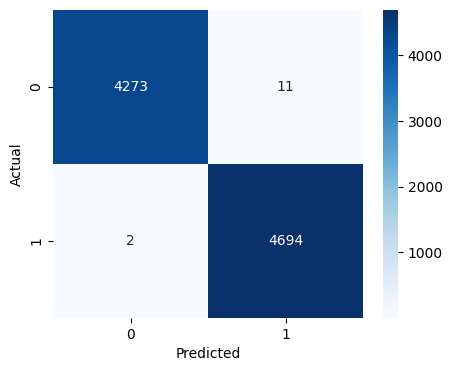

In [16]:
# 12) Evaluate
pred_probs = model.predict(X_test_pad, batch_size=256)
preds = (pred_probs >= 0.5).astype(int).reshape(-1)


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print('\nBiLSTM classification report:\n')
print(classification_report(y_test, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, pred_probs))


# confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

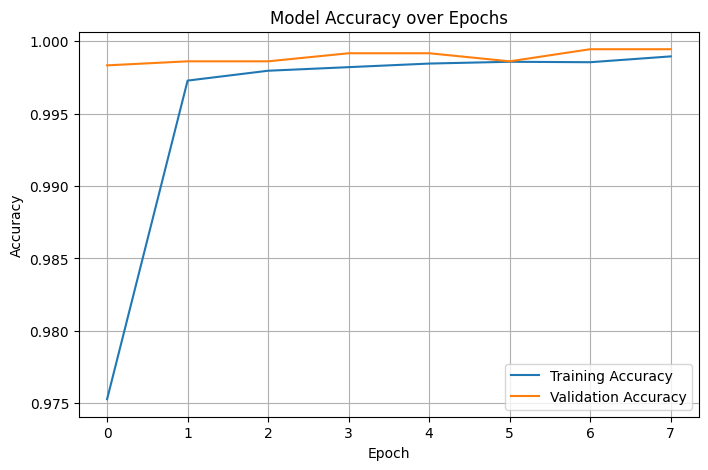

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [18]:
# Interactive testing cell — paste this into Colab and run it
# Requires: ./artifacts/tokenizer.pkl and ./artifacts/bilstm_model.h5 or ./artifacts/bilstm_model.keras

import os
import pickle
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
import numpy as np

# Ensure NLTK stopwords are available
nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))

# --- Load tokenizer ---
tk_path = './artifacts/tokenizer.pkl'
if not os.path.exists(tk_path):
    raise FileNotFoundError(f"Tokenizer not found at {tk_path}. Make sure tokenizer.pkl is in ./artifacts")

with open(tk_path, 'rb') as f:
    tokenizer = pickle.load(f)

# --- Load model (try .keras then .h5) ---
model = None
for candidate in ['./artifacts/bilstm_model.keras', './artifacts/bilstm_model.h5', './artifacts/best_bilstm.h5']:
    if os.path.exists(candidate):
        print(f"Loading model from: {candidate}")
        model = load_model(candidate)
        break
if model is None:
    raise FileNotFoundError("No model file found in ./artifacts. Expected bilstm_model.keras or bilstm_model.h5")

# Use same MAX_LEN you trained with
MAX_LEN = 300

# Cleaning function (must match training preprocessing)
def clean_text(text, remove_stopwords=True):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r'[^a-z ]', " ", text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)

# Prediction helper
def predict_article(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)
    # model.predict returns shape (1,1) or (1,) depending on Keras version
    prob_val = float(np.squeeze(prob))
    label = "Fake" if prob_val >= 0.5 else "Real"
    return label, prob_val

# --- Interactive loop: enter headlines one-by-one ---
print("Interactive Fake/Real tester\nType/paste a headline or article text and press Enter.\nLeave blank and press Enter to exit.\n")

while True:
    user_input = input("Enter headline/text (blank to quit): ").strip()
    if user_input == "":
        print("Exiting interactive tester.")
        break
    label, prob = predict_article(user_input)
    print(f"→ Prediction: {label} (confidence: {prob:.4f})\n")


Loading model from: ./artifacts/best_bilstm.h5
Interactive Fake/Real tester
Type/paste a headline or article text and press Enter.
Leave blank and press Enter to exit.

Enter headline/text (blank to quit): The U.S. House of Representatives on Thursday took a step toward averting a partial government shutdown at the end of this week, approving rules to debate a bill that would fund federal agencies through Jan. 19. Also cleared for debate was an $81 billion disaster aid bill to help U.S. states, Puerto Rico and the U.S. Virgin Islands recover from a series of recent natural disasters. House votes on both bills were expected later on Thursday. 
→ Prediction: Fake (confidence: 0.9965)

Enter headline/text (blank to quit):  WASHINGTON (Reuters) - The U.S. House of Representatives on Thursday took a step toward averting a partial government shutdown at the end of this week, approving rules to debate a bill that would fund federal agencies through Jan. 19. Also cleared for debate was an $81 